## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

## Loading Data

In [4]:
cols = ['tweet_id', 'entity', 'sentiment', 'text']
df = pd.read_csv('twitter_training.csv', header=None, names=cols)

print("Shape:", df.shape)
df.head()

Shape: (74682, 4)


,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   74682 non-null  int64
 1   entity     74682 non-null  str  
 2   sentiment  74682 non-null  str  
 3   text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


## Data Cleaning

In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64

Duplicate rows: 2700


In [7]:
df_clean = df.dropna(subset=['text']).drop_duplicates().reset_index(drop=True)
print("Shape before cleaning:", df.shape)
print("Shape after cleaning: ", df_clean.shape)

Shape before cleaning: (74682, 4)
Shape after cleaning:  (71656, 4)


In [8]:
df_clean['sentiment'].value_counts()

sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64

In [9]:
df_clean['entity'].value_counts()

entity
TomClancysRainbowSix                 2328
Verizon                              2319
MaddenNFL                            2315
CallOfDuty                           2314
Microsoft                            2304
WorldOfCraft                         2300
NBA2K                                2299
LeagueOfLegends                      2296
TomClancysGhostRecon                 2291
Facebook                             2289
ApexLegends                          2278
johnson&johnson                      2257
Battlefield                          2255
Amazon                               2249
CallOfDutyBlackopsColdWar            2242
FIFA                                 2238
Dota2                                2225
Overwatch                            2220
Hearthstone                          2219
HomeDepot                            2216
GrandTheftAuto(GTA)                  2208
Borderlands                          2206
Xbox(Xseries)                        2201
Google                     

## Overall Sentiment Distribution

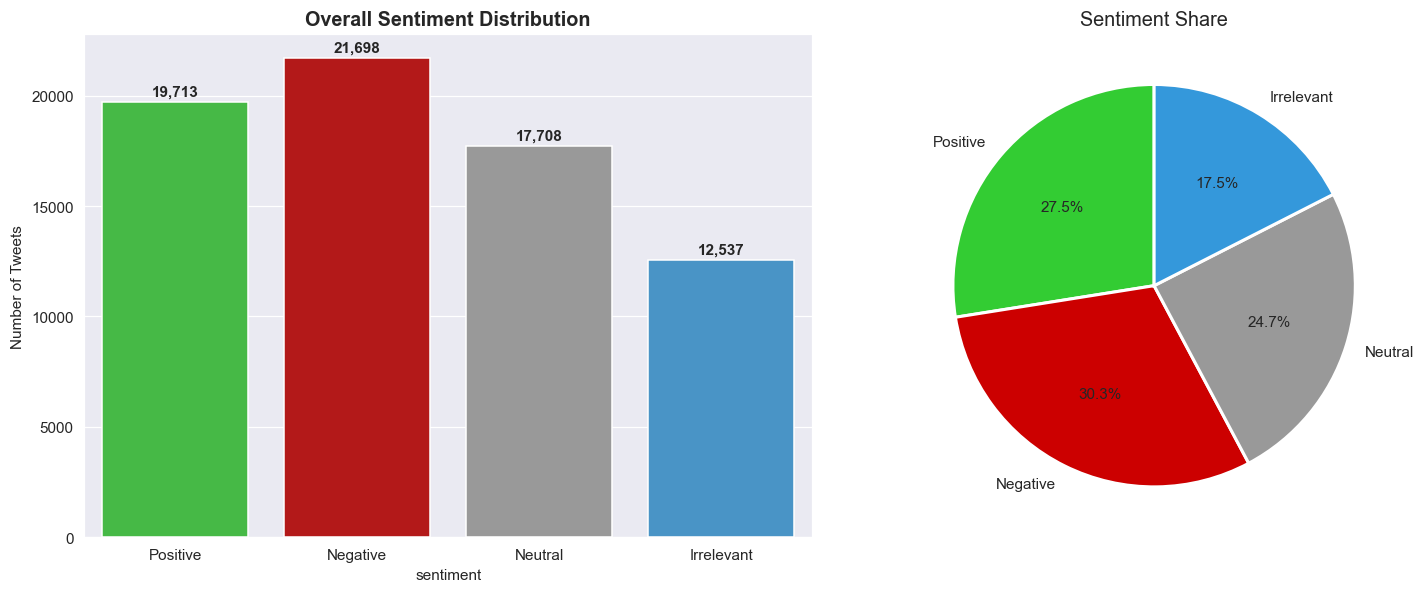

In [10]:
sentiment_order = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
palette = {'Positive': '#33cc33', 'Negative': '#cc0000', 'Neutral': '#999999', 'Irrelevant': '#3498db'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

counts = df_clean['sentiment'].value_counts().reindex(sentiment_order)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=palette, legend=False, ax=axes[0])

axes[0].set_title('Overall Sentiment Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[palette[s] for s in counts.index], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Share', fontsize=13, fontweight='light')

plt.tight_layout()
plt.show()

## Sentiment Breakdown by Brand / Entity

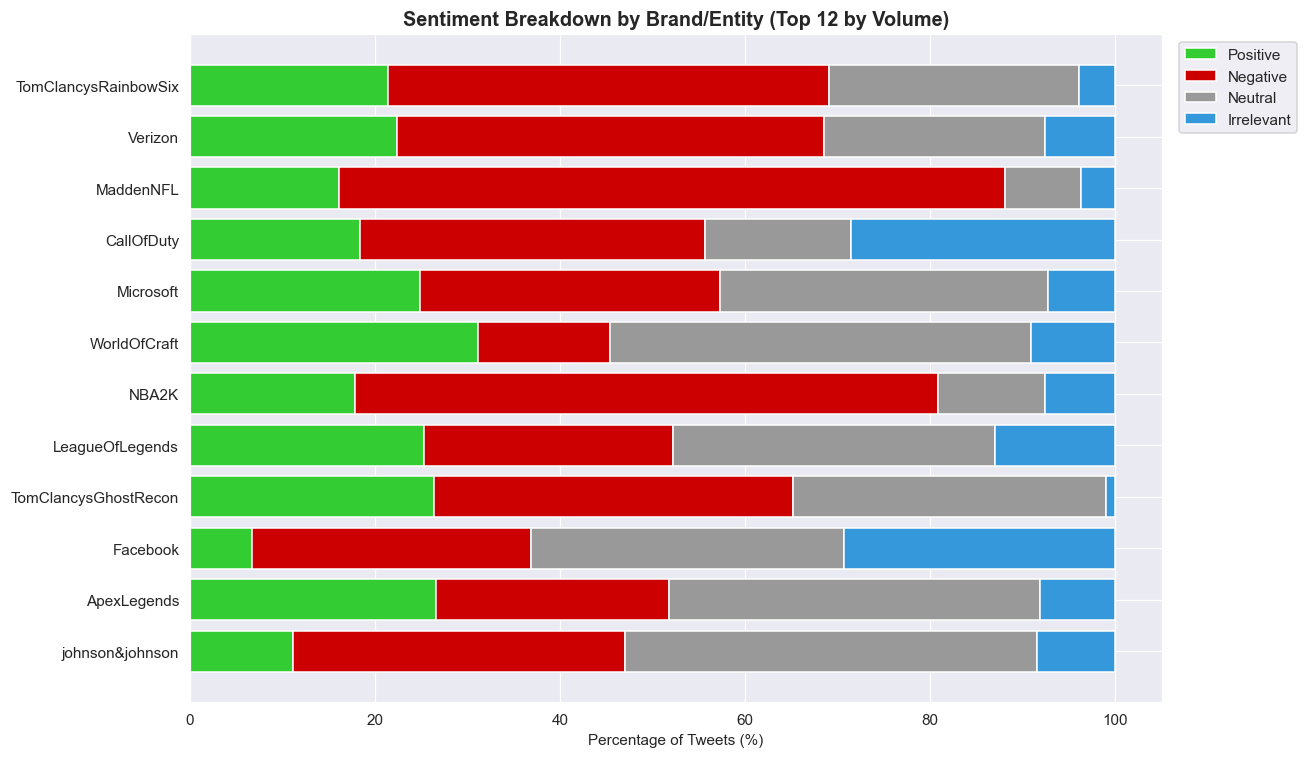

In [11]:
top_entities = df_clean['entity'].value_counts().head(12).index
sub = df_clean[df_clean['entity'].isin(top_entities)]

ct = pd.crosstab(sub['entity'], sub['sentiment'], normalize='index')[sentiment_order] * 100
ct = ct.loc[top_entities]

fig, ax = plt.subplots(figsize=(12, 7))
bottom = np.zeros(len(ct))
for s in sentiment_order:
    ax.barh(ct.index, ct[s], left=bottom, color=palette[s], label=s)
    bottom += ct[s].values

ax.set_xlabel('Percentage of Tweets (%)')
ax.set_title('Sentiment Breakdown by Brand/Entity (Top 12 by Volume)', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Net Sentiment Score by Entity

In [12]:
relevant = df_clean[df_clean['sentiment'] != 'Irrelevant']
pivot = relevant.groupby(['entity', 'sentiment']).size().unstack(fill_value=0)
pivot['total'] = pivot.sum(axis=1)
pivot['net_sentiment'] = (pivot.get('Positive', 0) - pivot.get('Negative', 0)) / pivot['total']
pivot_sorted = pivot.sort_values('net_sentiment', ascending=False)

In [13]:
print("Top 5 most positively received:")
print(pivot_sorted[['Positive', 'Negative', 'net_sentiment']].head(5))
print("\nBottom 5 most negatively received:")
print(pivot_sorted[['Positive', 'Negative', 'net_sentiment']].tail(5))

Top 5 most positively received:
sentiment               Positive  Negative  net_sentiment
entity                                                   
AssassinsCreed              1382       365       0.535263
Cyberpunk2077                902       360       0.315483
RedDeadRedemption(RDR)       885       290       0.304972
Borderlands                  972       415       0.283028
PlayStation5(PS5)            890       422       0.259711

Bottom 5 most negatively received:
sentiment             Positive  Negative  net_sentiment
entity                                                 
TomClancysRainbowSix       498      1110      -0.273703
Facebook                   154       690      -0.331478
FIFA                       473      1127      -0.384706
NBA2K                      409      1450      -0.490113
MaddenNFL                  373      1665      -0.579632


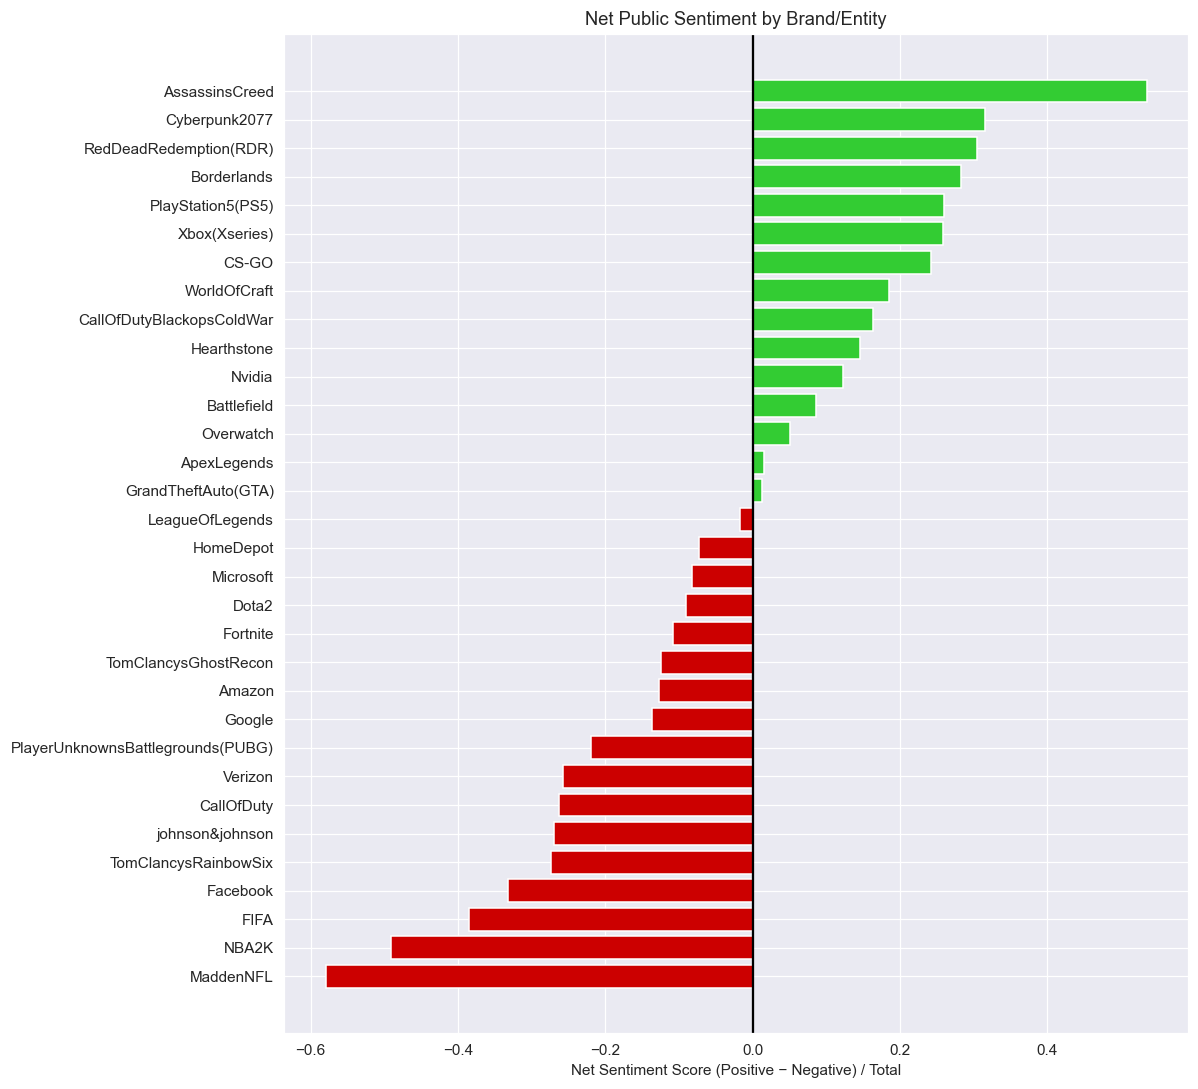

In [20]:
pivot_ranked = pivot.sort_values('net_sentiment')

fig, ax = plt.subplots(figsize=(11, 10))

ax.barh(
    pivot_ranked.index,
    pivot_ranked['net_sentiment'],
    color=['#cc0000' if x < 0 else '#33cc33' for x in pivot_ranked['net_sentiment']]
)

plt.axvline(0, color='black')
plt.xlabel('Net Sentiment Score (Positive − Negative) / Total')
plt.title('Net Public Sentiment by Brand/Entity')

plt.tight_layout()
plt.show()

## Tweet Length by Sentiment

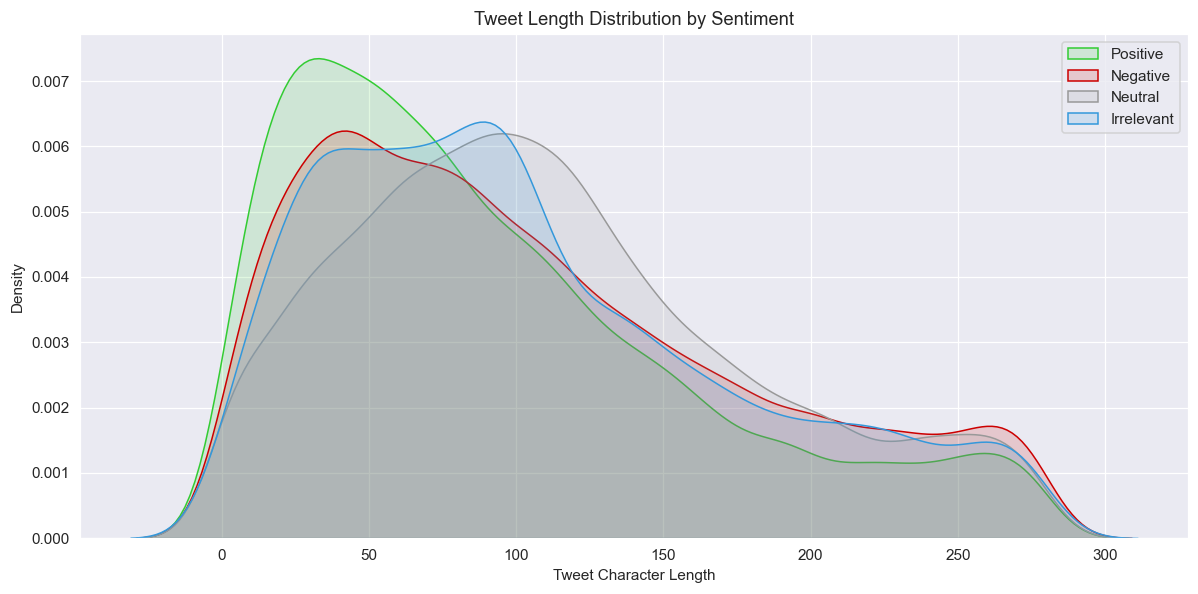

sentiment
Irrelevant    112.1
Negative      113.4
Neutral       119.6
Positive       98.3
Name: text_length, dtype: float64


In [27]:
df_clean['text_length'] = df_clean['text'].astype(str).apply(len)
df_trim = df_clean[df_clean['text_length'] < 280]

fig, ax = plt.subplots(figsize=(11, 5.5))
for s in sentiment_order:
    sns.kdeplot(df_trim[df_trim['sentiment'] == s]['text_length'],
                label=s, color=palette[s], fill=True, alpha=0.15, ax=ax)
    
plt.xlabel('Tweet Character Length')
plt.ylabel('Density')
plt.title('Tweet Length Distribution by Sentiment')
ax.legend()
plt.tight_layout()
plt.show()

print(df_clean.groupby('sentiment')['text_length'].mean().round(1))

## What People Are Actually Saying
Word clouds for Positive and Negative tweets highlight the most frequent (non-generic) words in each class

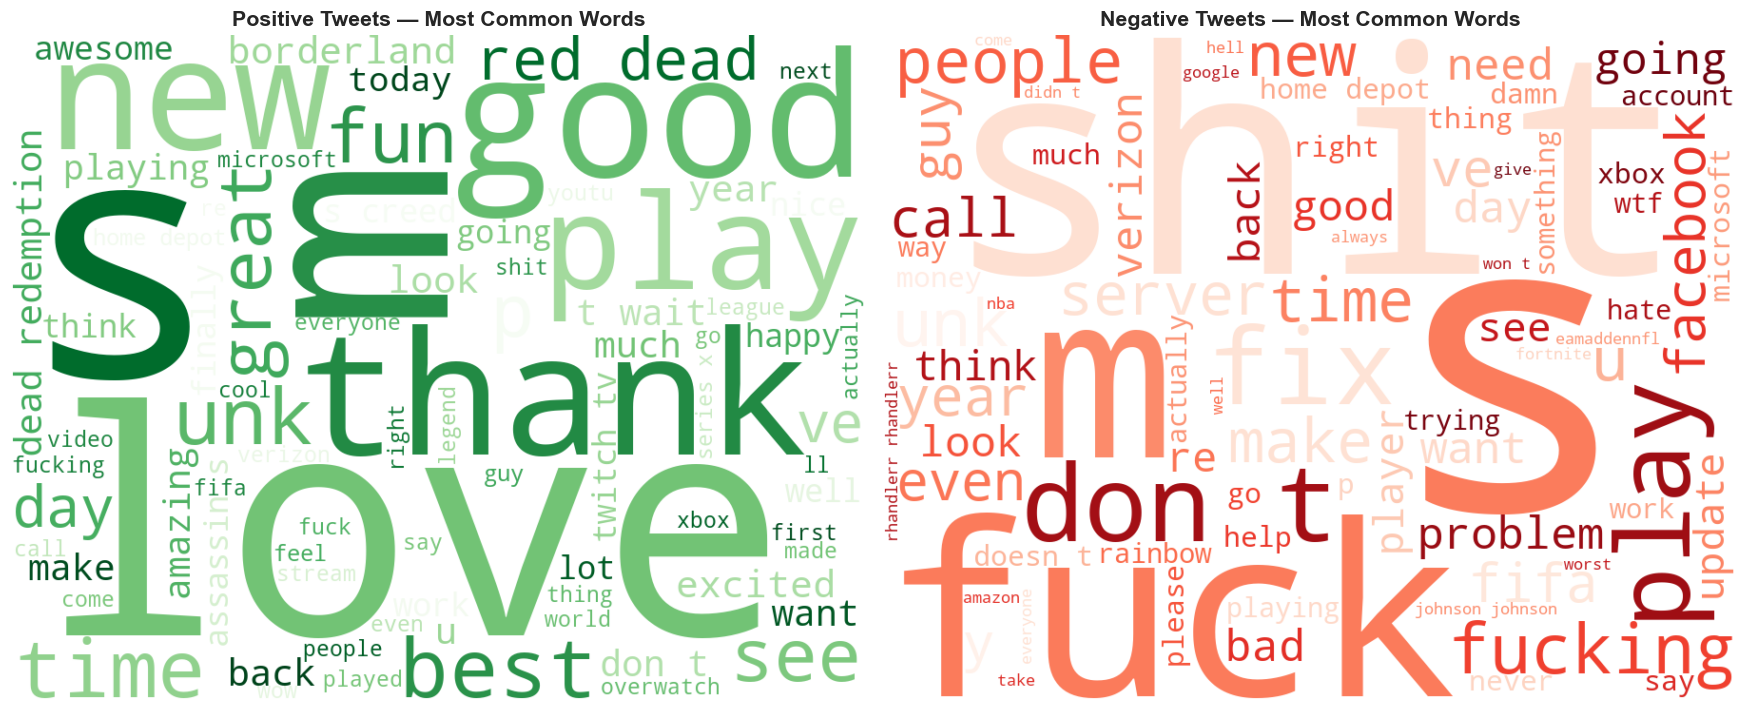

In [29]:
stopwords_extra = {'im', 'ill', 'will', 'get', 'getting', 'got', 'one', 'now', 'still',
                    'know', 'dont', 'like', 'just', 'really', 'game', 'games',
                    'http', 'https', 'co', 'com', 'pic', 'twitter'}

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http\S+|pic\.twitter\.com/\S+', '', t)
    t = re.sub(r'@\w+', '', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return t

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, sentiment, cmap in zip(axes, ['Positive', 'Negative'], ['Greens', 'Reds']):
    text = ' '.join(df_clean[df_clean['sentiment'] == sentiment]['text'].apply(clean_text))
    wc = WordCloud(width=900, height=700, background_color='white', colormap=cmap,
                    stopwords=WordCloud().stopwords.union(stopwords_extra),
                    max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Tweets — Most Common Words', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()